In [1]:
from ete3 import Tree
from Bio import Phylo
from io import StringIO
import os
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import ete3
ete3.__version__

'3.1.3'

In [3]:
import numpy as np
import seaborn as sns

In [4]:
from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm

In [5]:

def branching_factor(tree):
    bf = []
    for i in tree.get_nonterminals():
        bf.append(len(i.clades))
    bf = np.array(bf)
    return bf[bf>1]

In [6]:
def allel_edit_distance(al1, al2):
    n = len(al1)
    diff, cnt = 0, 0
    for i in range(n):
        if (al1[i] == '_') or (al2[i] == '_'):
            continue
        cnt += 1
        if al1[i] != al2[i]:
            if (al1[i] == 0) or (al2[i] == 0) or (al1[i] == '0') or (al2[i] == '0'):
                diff += 1
            else:
                diff += 2
    return diff / cnt           

def phylogenetic_distance(tree, node1, node2):
    return tree.distance(node1, node2)

In [10]:
PEtracer_tree_list = pd.read_csv('/syn1/liangzhen/jinhua_jilab_project/data/PEtracer/newick_trees/tree.list', sep='\t')
PEtracer_tree_list
PEtracer_tree = {'terminal':[], 'nonterminal':[], 'branching_factor':[]}
data_path = '/syn1/liangzhen/jinhua_jilab_project/data/PEtracer/newick_trees/'
cell_num = 0
for i in tqdm(PEtracer_tree_list['sample']):
    with open(data_path+i, 'r') as f:
        tree_nwk = f.readline()
    t = Tree(tree_nwk,format=1)
    cell_num = cell_num + len(t.get_leaves())
    f = StringIO(t.write())
    tree = Phylo.read(f, 'newick')
    f.close()
    PEtracer_tree['terminal'].append(len(tree.get_terminals()))
    PEtracer_tree['nonterminal'].append(len(tree.get_nonterminals()))
    PEtracer_tree['branching_factor'].append(branching_factor(tree).mean())


100%|██████████| 12/12 [00:02<00:00,  4.58it/s]


In [11]:
cell_num

51018

In [15]:
len(t.get_leaves())

10061

In [16]:
eTRACER_spatial_tree_list = pd.read_csv('/syn1/liangzhen/jinhua_jilab_project/result/DNA_Amplicon/SPATIAL/T2/trees/bin50_align_reads10/EE_tree/tree.list', sep='\t')
eTRACER_spatial_tree_list
bin50_num = 0
eTRACER_spatial_tree = {'terminal':[], 'nonterminal':[], 'branching_factor':[]}
data_path = '/syn1/liangzhen/jinhua_jilab_project/result/DNA_Amplicon/SPATIAL/T2/trees/bin50_align_reads10/EE_tree/'
for i in tqdm(eTRACER_spatial_tree_list['sample']):
    with open(data_path+i, 'r') as f:
        tree_nwk = f.readline()
    t = Tree(tree_nwk,format=1)
    bin50_num = bin50_num + len(t.get_leaves())
    f = StringIO(t.write())
    tree = Phylo.read(f, 'newick')
    f.close()
    eTRACER_spatial_tree['terminal'].append(len(tree.get_terminals()))
    eTRACER_spatial_tree['nonterminal'].append(len(tree.get_nonterminals()))
    eTRACER_spatial_tree['branching_factor'].append(branching_factor(tree).mean())


100%|██████████| 22/22 [00:00<00:00, 31.30it/s]


In [17]:
bin50_num

12334

/tmp/ipykernel_339790/2501734389.py:35: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df, x="Group", y="Branching index", ax=ax,
/home/liangzhen/anaconda3/envs/cellrank2/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/liangzhen/anaconda3/envs/cellrank2/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


PEtracer_tree vs. eTRACER_saptial_tree: Mann-Whitney-Wilcoxon test two-sided, P_val:1.951e-05 U_stat=1.300e+01


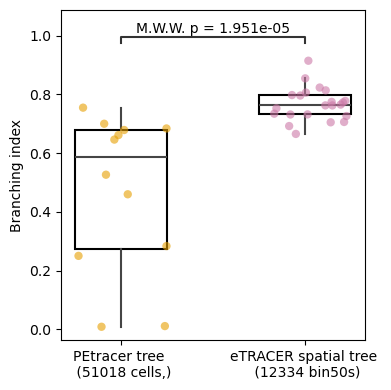

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from scipy.stats import ttest_ind


data = {
    'PEtracer_tree': np.array(PEtracer_tree['nonterminal'])/(np.array(PEtracer_tree['terminal'])-1),
    "eTRACER_saptial_tree": np.array(eTRACER_spatial_tree['nonterminal'])/(np.array(eTRACER_spatial_tree['terminal'])-1)
}

df = pd.DataFrame([(key, val) for key, values in data.items() for val in values], columns=["Group", "Branching index"])


palette = {
    "PEtracer_tree": "#E69F00",
    "eTRACER_saptial_tree": "#CC79A7"
}

pairs = [
    ("PEtracer_tree", "eTRACER_saptial_tree")
]


plt.rcParams['pdf.fonttype'] = 42
fig, ax = plt.subplots(figsize=(4, 4))

sns.boxplot(data=df, x="Group", y="Branching index", ax=ax,
            boxprops=dict(facecolor='none', edgecolor='black'),
            width=0.5, fliersize=0, capprops=dict(visible=False),
            palette=palette)

sns.stripplot(data=df, x="Group", y="Branching index", ax=ax,
              size=6, jitter=0.25, alpha=0.6,
              palette=palette)


annotator = Annotator(ax, pairs, data=df, x="Group", y="Branching index")
annotator.configure(test="Mann-Whitney", text_format="full", loc="inside", comparisons_correction=None)
annotator.apply_and_annotate()

ax.set_ylabel("Branching index")
ax.set_xlabel("")
ax.set_xticklabels(["PEtracer tree \n (51018 cells,)", "eTRACER spatial tree \n (12334 bin50s)"])
#ax.set_xticklabels(ax.get_xticklabels())

plt.tight_layout()
plt.savefig('/syn1/liangzhen/jinhua_jilab_project/result/Figures/Figure4/branch_index_spatial.pdf')
plt.show()
